# Analysis (reads the combined result files)
Deep-dive on ONE run: executive scorecard, cohort, claims, validation, N-regime comparison, telematics tiers, EV split, seed spread, realism checks. Every table/figure loops the PREM_ columns present in the file — no hardcoded regime trio.

Input: `shared/results/<scenario>_s<seed>.pkl` written by `run_scenarios.py` (`manifest.json` lists every run).

In [48]:
import os, sys
ROOT = os.path.abspath('')
if ROOT not in sys.path: sys.path.insert(0, ROOT)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from voltvision import (
    compare_all,
    ensure_core_methods,
    io,
    load_template,
    lr,
    lr_by,
    quote,
    reg_color,
    reg_label,
    resolve_cards,
    retained_lr,
    rho,
    summary,
)

%matplotlib inline

# --- Which run to dissect (manifest.json lists every scenario x seed) ---
SC, SEED_RUN = 'high_adopt_freq', 157
try:
    combined = io.load_result(SC, SEED_RUN)
except FileNotFoundError:
    SC, SEED_RUN = io.pick_result()  # fall back to the newest run in the manifest
    combined = io.load_result(SC, SEED_RUN)
raw = io.sim_book(combined)             # sim book: attributes + claims
books = io.books_from_result(combined)  # {regime: book with FINAL_PREMIUM_SST}
REGIMES_RUN = io.premium_columns(combined)
print(f'{SC}_s{SEED_RUN}: {len(raw)} rows, regimes = {REGIMES_RUN}')

high_adopt_freq_s157: 53825 rows, regimes = ['tariff', 'glm', 'telem']


## §1 Executive summary — one scorecard row per regime (N rows, N bars)

,Regime,LR (%),Retained LR (15%),Prem-count rho,Avg prem (RM)
0,Tariff,80.96,81.75,0.322,891.0
1,GLM,70.81,66.67,0.435,1019.0
2,GLM+Telematics,71.03,67.80,0.427,1016.0


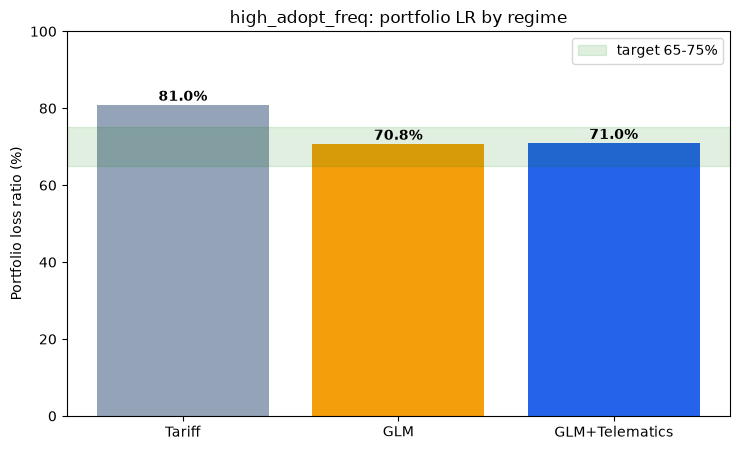

In [49]:
# Scorecard shared with the desk and runner: LR, retained LR, alignment, premium.
tab = compare_all(books)
display(tab)
fig, ax = plt.subplots(figsize=(max(7.5, 2.2 * len(tab)), 4.6))
bars = ax.bar(tab['Regime'], tab['LR (%)'], color=[reg_color(m) for m in REGIMES_RUN])
for b, v in zip(bars, tab['LR (%)']):
    ax.text(b.get_x() + b.get_width() / 2, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
ax.axhspan(65, 75, color='green', alpha=0.12, label='target 65-75%')
ax.set_ylim(0, max(100, tab['LR (%)'].max() + 10))
ax.set_ylabel('Portfolio loss ratio (%)'); ax.set_title(f'{SC}: portfolio LR by regime')
ax.legend(); plt.tight_layout(); plt.show()


## §2 Portfolio & cohort — what the book looks like, how it evolves

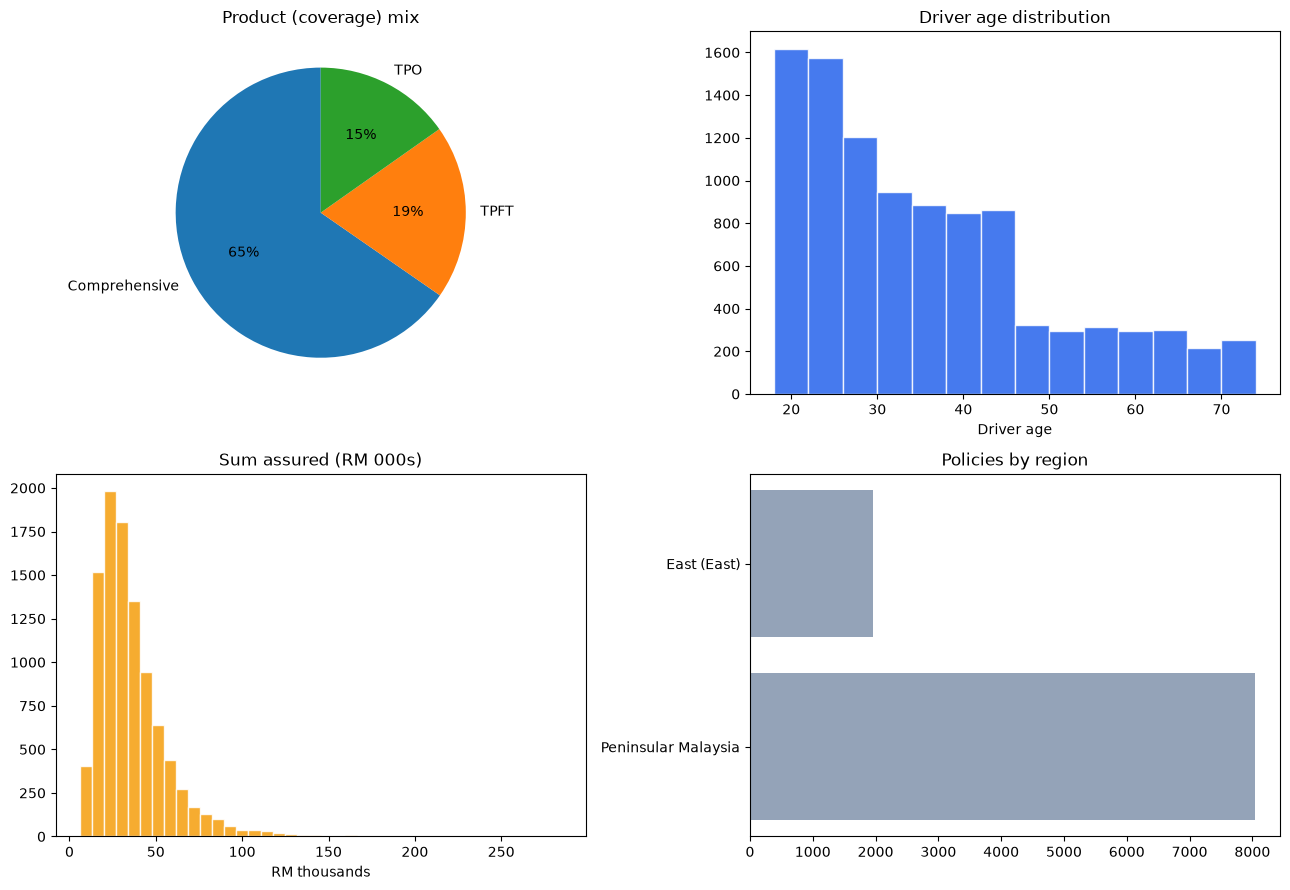

vehicle mix at inception: {'ICE': 0.959, 'EV': 0.041}


Year,Active policies,Claims,Freq,Avg NCD priced,Retention,Comp %,TPFT %,TPO %
2026,10000,1206,11.2%,24.6%,88.9%,65.3%,19.4%,15.2%
2027,10255,1260,11.4%,32.9%,90.0%,64.9%,19.7%,15.3%
2028,10663,1327,11.5%,35.7%,90.8%,64.5%,20.1%,15.4%
2029,11189,1302,11.0%,37.9%,90.6%,64.1%,20.3%,15.7%
2030,11718,1299,10.3%,39.4%,91.4%,63.7%,20.5%,15.8%


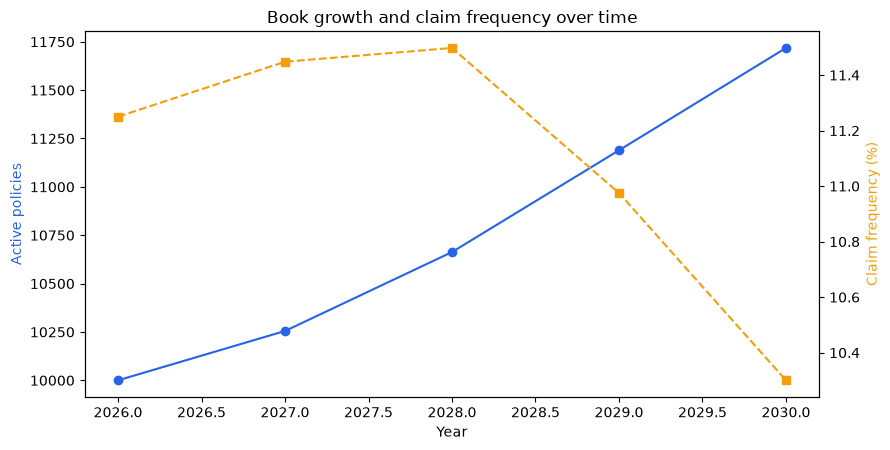

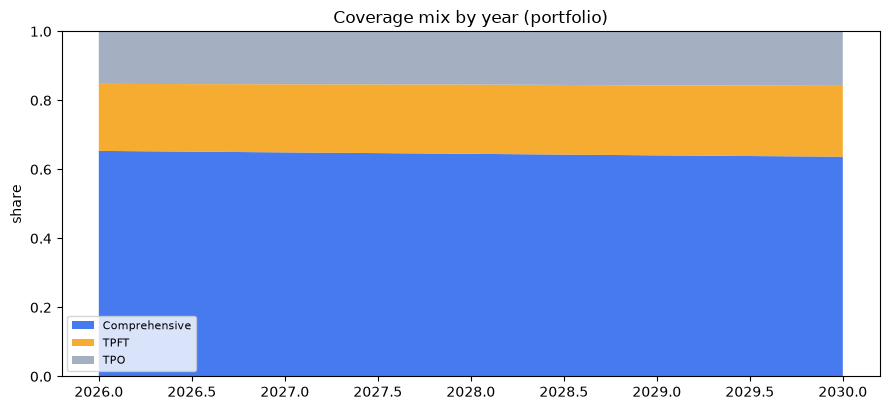

In [50]:
# Inception snapshot (first SIM_YEAR): product mix, driver ages, sums assured, regions.
d0 = raw[raw.SIM_YEAR == raw.SIM_YEAR.min()]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
cov_pct = d0['COVERAGE_TYPE'].value_counts(normalize=True) * 100
axes[0, 0].pie(cov_pct.values, labels=cov_pct.index, autopct='%.0f%%', startangle=90)
axes[0, 0].set_title('Product (coverage) mix')
axes[0, 1].hist(d0['DRIVER_AGE'], bins=range(18, 76, 4), color='#2563eb', edgecolor='white', alpha=0.85)
axes[0, 1].set_title('Driver age distribution'); axes[0, 1].set_xlabel('Driver age')
axes[1, 0].hist(d0['SUM_ASSURED'] / 1000, bins=40, color='#f59e0b', edgecolor='white', alpha=0.85)
axes[1, 0].set_title('Sum assured (RM 000s)'); axes[1, 0].set_xlabel('RM thousands')
reg = d0['REGION'].str.replace(' Malaysia (Sabah, Sawarak & Labuan)', ' (East)', regex=False).value_counts()
axes[1, 1].barh(reg.index, reg.values, color='#94a3b8')
axes[1, 1].set_title('Policies by region')
plt.tight_layout(); plt.show()
print('vehicle mix at inception:', d0['VEHICLE_TYPE'].value_counts(normalize=True).round(3).to_dict())

# Cohort evolution: growth, frequency, priced NCD, retention and coverage mix per year.
# Coverage shares move only when `coverage_ramp` is set (entrant mix converges).
rows = []
for y in sorted(raw.SIM_YEAR.unique()):
    yd = raw[raw.SIM_YEAR == y]
    rows.append({'Year': y, 'Active policies': len(yd), 'Claims': int(yd['CLAIM_COUNT'].sum()),
                 'Freq': yd['CLAIM_OCCURRED'].mean(), 'Avg NCD priced': yd['NCD_LEVEL_PRICED'].mean(),
                 'Retention': yd['RENEWED'].mean(),
                 'Comp %': (yd['COVERAGE_TYPE'] == 'Comprehensive').mean(),
                 'TPFT %': (yd['COVERAGE_TYPE'] == 'TPFT').mean(),
                 'TPO %': (yd['COVERAGE_TYPE'] == 'TPO').mean()})
cs = pd.DataFrame(rows)
display(cs.style.format({'Freq': '{:.1%}', 'Avg NCD priced': '{:.1%}', 'Retention': '{:.1%}',
                         'Comp %': '{:.1%}', 'TPFT %': '{:.1%}', 'TPO %': '{:.1%}'}).hide(axis='index'))
fig, ax1 = plt.subplots(figsize=(9, 4.6))
ax1.plot(cs.Year, cs['Active policies'], '-o', color='#2563eb', label='Active policies')
ax1.set_xlabel('Year'); ax1.set_ylabel('Active policies', color='#2563eb')
ax2 = ax1.twinx()
ax2.plot(cs.Year, cs['Freq'] * 100, '--s', color='#f59e0b', label='Claim frequency %')
ax2.set_ylabel('Claim frequency (%)', color='#f59e0b')
ax1.set_title('Book growth and claim frequency over time')
plt.tight_layout(); plt.show()

# Coverage mix by year (portfolio): flat without a ramp, drifting with one.
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.stackplot(cs.Year, cs['Comp %'], cs['TPFT %'], cs['TPO %'],
             labels=['Comprehensive', 'TPFT', 'TPO'],
             colors=['#2563eb', '#f59e0b', '#94a3b8'], alpha=0.85)
ax.set_title('Coverage mix by year (portfolio)')
ax.set_ylabel('share'); ax.set_ylim(0, 1)
ax.legend(loc='lower left', fontsize=8)
plt.tight_layout(); plt.show()

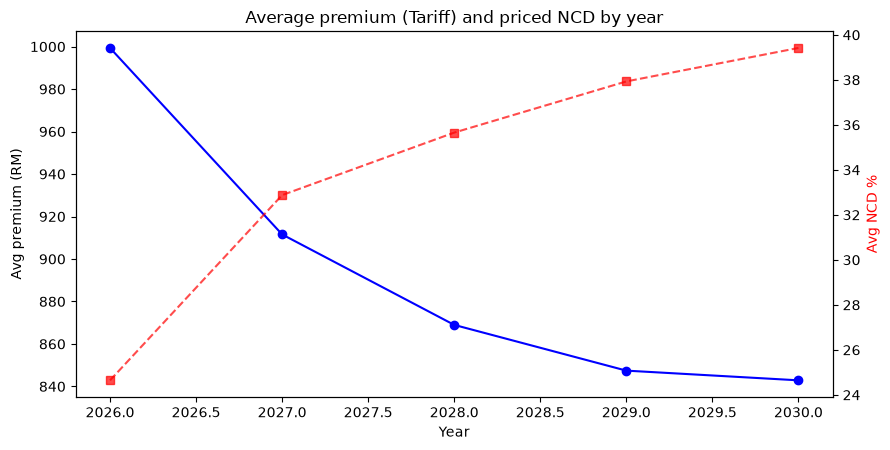

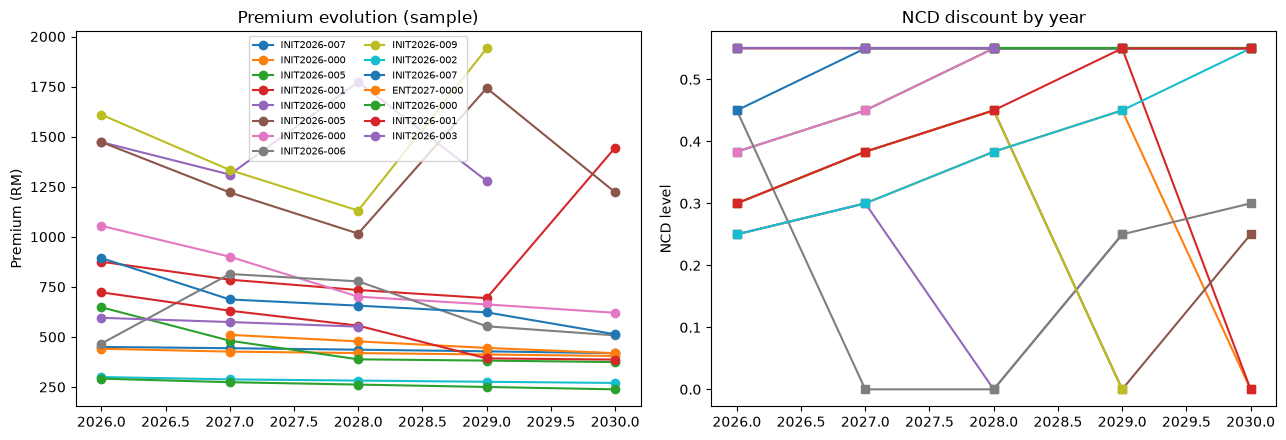

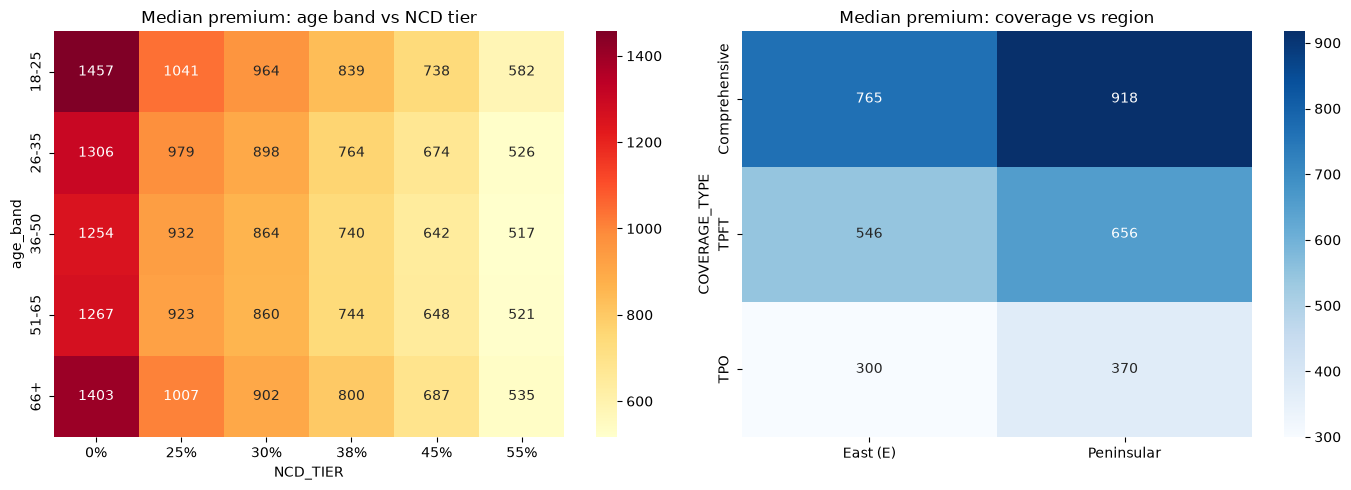

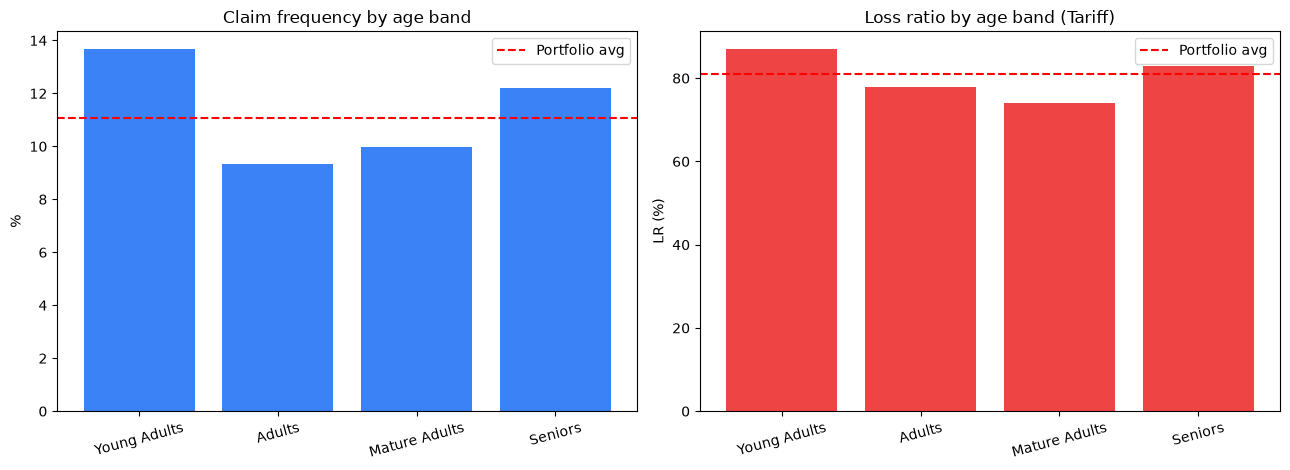

In [51]:
# Premium pressure vs loyalty: tariff avg premium (twin axis: priced NCD).
# First regime's book stands in — claims are identical across regimes.
ref = books[REGIMES_RUN[0]]
fig, ax1 = plt.subplots(figsize=(9, 4.6))
ax1.plot(sorted(ref.SIM_YEAR.unique()),
         ref.groupby('SIM_YEAR')['FINAL_PREMIUM_SST'].mean().values, 'b-o', label='Avg premium')
ax1.set_xlabel('Year'); ax1.set_ylabel('Avg premium (RM)')
ax2 = ax1.twinx()
ax2.plot(sorted(raw.SIM_YEAR.unique()),
         raw.groupby('SIM_YEAR')['NCD_LEVEL_PRICED'].mean().values * 100, 'r--s', alpha=0.7, label='Avg NCD %')
ax2.set_ylabel('Avg NCD %', color='red')
ax1.set_title(f'Average premium ({reg_label(REGIMES_RUN[0])}) and priced NCD by year')
plt.tight_layout(); plt.show()

# Sample policy trails: 15 policies with 3+ years, premium + NCD paths.
ny = raw.groupby('POLID')['SIM_YEAR'].nunique()
picks = list(np.random.RandomState(42).choice(ny[ny >= 3].index, size=15, replace=False))
sel = ref[ref.POLID.isin(picks)]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for pid in picks:
    p = sel[sel.POLID == pid].sort_values('SIM_YEAR')
    axes[0].plot(p.SIM_YEAR, p.FINAL_PREMIUM_SST, marker='o', label=str(pid)[:12])
    axes[1].plot(p.SIM_YEAR, p.NCD_LEVEL, marker='s')
axes[0].set_title('Premium evolution (sample)'); axes[0].set_ylabel('Premium (RM)')
axes[0].legend(fontsize=7, ncol=2)
axes[1].set_title('NCD discount by year'); axes[1].set_ylabel('NCD level')
plt.tight_layout(); plt.show()

# Median premium surfaces: age band x NCD tier, coverage x region.
fd = ref.copy()
fd['NCD_TIER'] = fd.NCD_LEVEL.map({0.0: '0%', 0.25: '25%', 0.30: '30%', 0.3833: '38%', 0.45: '45%', 0.55: '55%'})
fd['age_band'] = pd.cut(fd.DRIVER_AGE, bins=[17, 25, 35, 50, 65, 100],
                        labels=['18-25', '26-35', '36-50', '51-65', '66+'])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(fd.groupby(['age_band', 'NCD_TIER'], observed=True)['FINAL_PREMIUM_SST'].median().unstack(),
            annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Median premium: age band vs NCD tier')
p2 = fd.groupby(['COVERAGE_TYPE', 'REGION'], observed=True)['FINAL_PREMIUM_SST'].median().unstack()
p2.columns = [c.replace(' Malaysia (Sabah, Sawarak & Labuan)', ' (E)').replace(' Malaysia', '') for c in p2.columns]
sns.heatmap(p2, annot=True, fmt='.0f', cmap='Blues', ax=axes[1])
axes[1].set_title('Median premium: coverage vs region')
plt.tight_layout(); plt.show()

# U-shaped age risk: frequency + LR per driver band vs portfolio average.
cats = ['Young Adults', 'Adults', 'Mature Adults', 'Seniors']
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
freq_age = ref.groupby('DRIVER_AGE_CAT', observed=True)['CLAIM_OCCURRED'].mean().reindex(cats) * 100
axes[0].bar(freq_age.index, freq_age.values, color='#3b82f6')
axes[0].axhline(ref['CLAIM_OCCURRED'].mean() * 100, ls='--', color='red', label='Portfolio avg')
axes[0].set_title('Claim frequency by age band'); axes[0].set_ylabel('%')
axes[0].legend(); axes[0].tick_params(axis='x', rotation=15)
lr_age = pd.Series({c: lr(ref[ref.DRIVER_AGE_CAT == c]) for c in cats})
axes[1].bar(lr_age.index, lr_age.values, color='#ef4444')
axes[1].axhline(lr(ref), ls='--', color='red', label='Portfolio avg')
axes[1].set_title(f'Loss ratio by age band ({reg_label(REGIMES_RUN[0])})'); axes[1].set_ylabel('LR (%)')
axes[1].legend(); axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()


## §3 Claims profile — frequency, severity, peril mix, LR by coverage (counts are regime-independent; LR shown for every regime)

Coverage,Policies,Freq,Claims,Sev/claim (RM),LR Tariff (%),LR GLM (%),LR GLM+Telematics (%)
Comprehensive,34698,13.2%,"4,971","5,068",69.0,75.3,75.6
TPFT,10782,7.9%,894,"9,359",102.8,80.7,81.0
TPO,8345,6.1%,529,"9,967",159.5,47.9,47.9


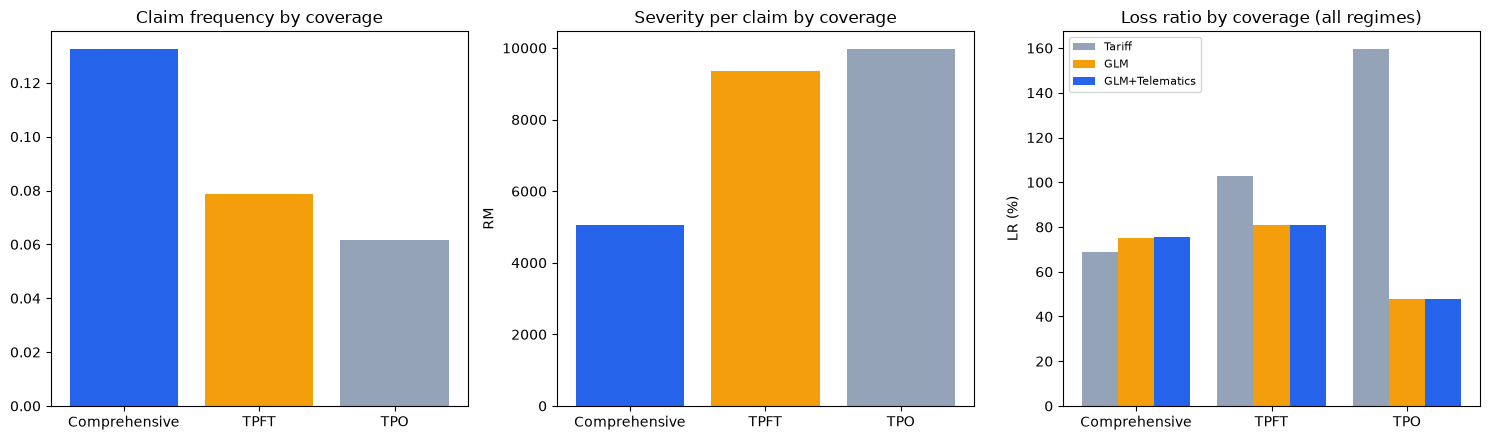

In [52]:
# Claims don't depend on pricing — one table from raw; LR computed per regime.
rows = []
for cov in ('Comprehensive', 'TPFT', 'TPO'):
    sub = raw[raw.COVERAGE_TYPE == cov]
    n = sub['CLAIM_COUNT'].sum()
    row = {'Coverage': cov, 'Policies': len(sub), 'Freq': sub['CLAIM_OCCURRED'].mean(),
           'Claims': int(n), 'Sev/claim (RM)': round(sub['CLAIM_AMOUNT'].sum() / n, 0) if n else 0}
    for regime in REGIMES_RUN:
        b = books[regime]
        row[f'LR {reg_label(regime)} (%)'] = round(lr(b[b.COVERAGE_TYPE == cov]), 1)
    rows.append(row)
cdf = pd.DataFrame(rows)
fmt = {'Freq': '{:.1%}', 'Sev/claim (RM)': '{:,.0f}', 'Claims': '{:,.0f}'}
fmt.update({f'LR {reg_label(r)} (%)': '{:.1f}' for r in REGIMES_RUN})
display(cdf.style.format(fmt).hide(axis='index'))
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].bar(cdf['Coverage'], cdf['Freq'], color=['#2563eb', '#f59e0b', '#94a3b8'])
axes[0].set_title('Claim frequency by coverage')
axes[1].bar(cdf['Coverage'], cdf['Sev/claim (RM)'], color=['#2563eb', '#f59e0b', '#94a3b8'])
axes[1].set_title('Severity per claim by coverage'); axes[1].set_ylabel('RM')
x = np.arange(len(cdf))
width = 0.8 / len(REGIMES_RUN)
for k, regime in enumerate(REGIMES_RUN):
    axes[2].bar(x + k * width - 0.4 + width / 2, cdf[f'LR {reg_label(regime)} (%)'],
                width, label=reg_label(regime), color=reg_color(regime))
axes[2].set_xticks(x); axes[2].set_xticklabels(cdf['Coverage'])
axes[2].set_title('Loss ratio by coverage (all regimes)'); axes[2].set_ylabel('LR (%)')
axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## §4 Validation — PASS/FAIL sanity checks + distribution tests (model trust)

In [53]:
# Cheap invariants first: any FAIL here stops trust in everything downstream.
res, checks = raw, []
add = lambda name, ok, detail='': checks.append({'Check': name, 'Pass': 'PASS' if ok else 'FAIL', 'Detail': detail})
add('Claim frequency within 10-20%', 0.10 <= res['CLAIM_OCCURRED'].mean() <= 0.20, f"{res['CLAIM_OCCURRED'].mean():.1%}")
add('TPO claim freq < Comprehensive',
    res.loc[res.COVERAGE_TYPE == 'TPO', 'CLAIM_OCCURRED'].mean() < res.loc[res.COVERAGE_TYPE == 'Comprehensive', 'CLAIM_OCCURRED'].mean())
add('Claims reset NCD to 0', (res.loc[res.CLAIM_OCCURRED, 'NCD_YEARS'] == 0).mean() >= 0.99)
add('Claim-free years increment NCD', (res.loc[~res.CLAIM_OCCURRED, 'NCD_YEARS'] >= 1).mean() >= 0.99)
add('No nulls in key fields', res[['CLAIM_COUNT', 'CLAIM_AMOUNT', 'CLAIM_LAMBDA', 'NCD_LEVEL', 'RENEWED']].isnull().sum().sum() == 0)
add('Mean driver age rises across years',
    res.groupby('SIM_YEAR')['DRIVER_AGE'].mean().iloc[-1] > res.groupby('SIM_YEAR')['DRIVER_AGE'].mean().iloc[0])
ev = res[res.CLAIM_PERIL.str.split('/').str[0].isin(['AD', 'Theft', 'Fire'])]
add('EV severity > ICE on own-damage perils',
    ev.loc[ev.VEHICLE_TYPE == 'EV', 'CLAIM_AMOUNT'].mean() > ev.loc[ev.VEHICLE_TYPE == 'ICE', 'CLAIM_AMOUNT'].mean())
t = pd.DataFrame(checks)
display(t)
print(f"core checks: {(t.Pass == 'PASS').sum()}/{len(t)} passed")
print('retention claimed vs clean:', res.groupby('CLAIM_OCCURRED')['RENEWED'].mean().round(3).to_dict())

# Distribution shape: log-premium ~ normal (mixture accepted), counts ~ Poisson,
# severity ~ gamma per coverage. KS < 0.20 passes (mixtures never fit perfectly).
from scipy.stats import kstest, norm, gamma as gamma_dist
prem = books[REGIMES_RUN[0]]['FINAL_PREMIUM_SST']
lp = np.log(prem)
ks_lp, _ = kstest(lp, norm(loc=lp.mean(), scale=lp.std()).cdf)
print(f'log-premium KS={ks_lp:.3f} (pass < 0.20) | skew={lp.skew():.3f}')
vm = res.CLAIM_COUNT.var() / res.CLAIM_COUNT.mean()
print(f'claim count var/mean={vm:.3f} (Poisson ~= 1; heterogeneity inflates)')
for cov in ['Comprehensive', 'TPFT', 'TPO']:
    s = res[(res.COVERAGE_TYPE == cov) & (res.CLAIM_AMOUNT > 0)].CLAIM_AMOUNT
    if len(s) > 30:
        sh, lo, sc = gamma_dist.fit(s, floc=0)
        ks, _ = kstest(s, gamma_dist(a=sh, loc=lo, scale=sc).cdf)
        print(f'{cov}: gamma shape={sh:.2f} KS={ks:.3f} mean=RM{s.mean():,.0f}')


,Check,Pass,Detail
0,Claim frequency within 10-20%,PASS,11.1%
1,TPO claim freq < Comprehensive,PASS,
2,Claims reset NCD to 0,PASS,
3,Claim-free years increment NCD,PASS,
4,No nulls in key fields,PASS,
5,Mean driver age rises across years,PASS,
6,EV severity > ICE on own-damage perils,PASS,


core checks: 7/7 passed
retention claimed vs clean: {False: 0.933, True: 0.674}
log-premium KS=0.017 (pass < 0.20) | skew=0.252
claim count var/mean=1.025 (Poisson ~= 1; heterogeneity inflates)
Comprehensive: gamma shape=0.57 KS=0.127 mean=RM6,399
TPFT: gamma shape=0.44 KS=0.048 mean=RM9,844
TPO: gamma shape=0.42 KS=0.101 mean=RM10,278


## §5 Pricing comparison — N regimes, one scorecard, effectiveness checks

,Regime,LR (%),Retained LR (15%),Prem-count rho,Avg prem (RM)
0,Tariff,80.96,81.75,0.322,891.0
1,GLM,70.81,66.67,0.435,1019.0
2,GLM+Telematics,71.03,67.80,0.427,1016.0


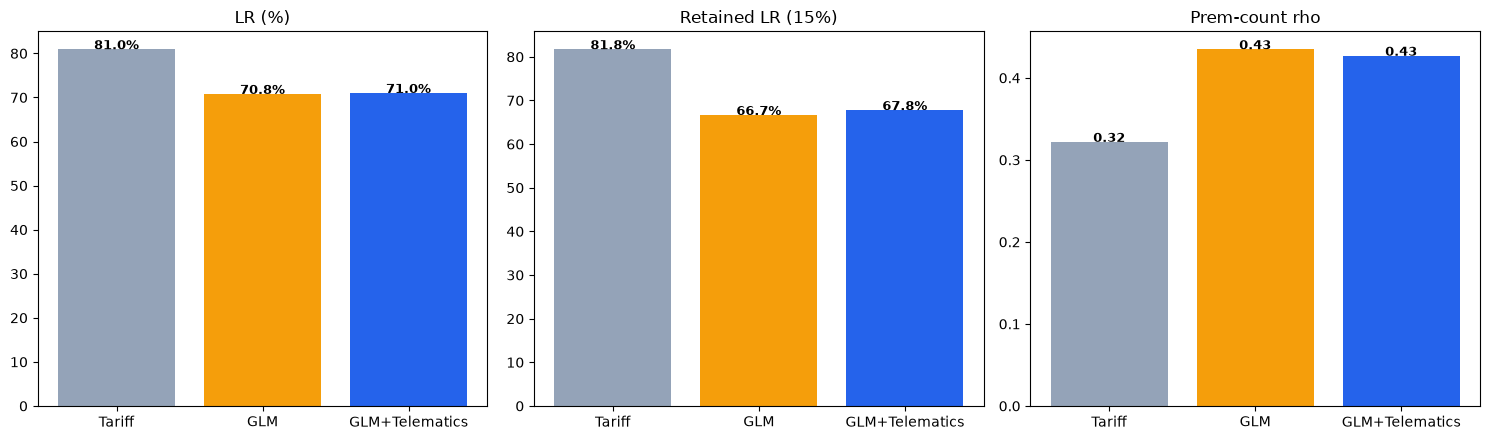

In [54]:
# Same scorecard as §1, plus one panel per metric — bars scale to N regimes.
pcd = compare_all(books)
display(pcd)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col, fmt in zip(axes, ['LR (%)', f"Retained LR ({0.15:.0%})", 'Prem-count rho'], ['{:.1f}%', '{:.1f}%', '{:.2f}']):
    bars = ax.bar(pcd['Regime'], pcd[col], color=[reg_color(m) for m in REGIMES_RUN])
    for b, v in zip(bars, pcd[col]):
        ax.text(b.get_x() + b.get_width() / 2, v, fmt.format(v), ha='center', fontweight='bold', fontsize=9)
    ax.set_title(col)
plt.tight_layout(); plt.show()


In [55]:
# Effectiveness checks (N-safe): risk signals separate claimants; the best
# risk-priced regime beats tariff on LR and retained LR; alignment reported.
ck, b0 = [], books[REGIMES_RUN[0]]
c13 = lambda name, ok, detail='': ck.append({'Check': name, 'Pass': 'PASS' if ok else 'FAIL', 'Detail': detail})
c13('Behavior risk higher for claimants',
    b0.loc[b0.CLAIM_OCCURRED, 'BEHAVIOR_RISK'].mean() > b0.loc[~b0.CLAIM_OCCURRED, 'BEHAVIOR_RISK'].mean())
c13('Telematics score lower for claimants',
    b0.loc[b0.CLAIM_OCCURRED, 'telematics_score'].mean() < b0.loc[~b0.CLAIM_OCCURRED, 'telematics_score'].mean())
lrs = {m: lr(b) for m, b in books.items()}
best = min(lrs, key=lrs.get)
c13(f'Best regime ({reg_label(best)}) LR < {reg_label(REGIMES_RUN[0])} LR',
    lrs[best] < lrs[REGIMES_RUN[0]], f"{lrs[best]:.1f}% vs {lrs[REGIMES_RUN[0]]:.1f}%")
rls = {m: retained_lr(b) for m, b in books.items()}
c13('Best retained LR < first-regime retained LR', min(rls.values()) < rls[REGIMES_RUN[0]])
rhos = {m: rho(b) for m, b in books.items()}
c13(f"Strongest alignment: {reg_label(max(rhos, key=rhos.get))} rho={max(rhos.values()):.3f}", True)
t = pd.DataFrame(ck)
display(t)
print(f'effectiveness: {(t.Pass == "PASS").sum()}/{len(t)} passed')


,Check,Pass,Detail
0,Behavior risk higher for claimants,PASS,
1,Telematics score lower for claimants,PASS,
2,Best regime (GLM) LR < Tariff LR,PASS,70.8% vs 81.0%
3,Best retained LR < first-regime retained LR,PASS,
4,Strongest alignment: GLM rho=0.435,PASS,


effectiveness: 5/5 passed


## §5b Cross-scenario comparison — the review table
Same regimes across books: tariff on ICE-only, combined, EV-only; the ML
regimes on EV-only. Rows: TPO loss ratio, average loss ratio, premium
lower/upper bound (min-max across policy-years), average premium.
Missing columns mean the scenario hasn't been simulated yet — run
`python run_scenarios.py` first.

In [56]:
# Build the review table from results on disk (same seed as this analysis).
pairs = [('ICE', 'tariff', 'Tariff ICE ONLY'),
         ('MIX', 'tariff', 'Tariff EV and ICE combined'),
         ('EV', 'tariff', 'Tariff EV ONLY'),
         ('EV', 'glm', 'GLM EV ONLY'),
         ('EV', 'telem', 'GLM + Telematics EV ONLY')]
rows, missing = {}, []
for sc, regime, label in pairs:
    try:
        b = io.books_from_result(io.load_result(sc, SEED_RUN))[regime]
    except FileNotFoundError:
        missing.append(f'{sc}/{regime}')
        continue
    rows[label] = {
        'TPO Loss Ratio (%)': round(lr(b[b.COVERAGE_TYPE == 'TPO']), 1),
        'Average Loss Ratio (%)': round(lr(b), 1),
        'Premium lower-upper bound (RM)':
            f"{b.FINAL_PREMIUM_SST.min():,.0f} - {b.FINAL_PREMIUM_SST.max():,.0f}",
        'Average premium (RM)': round(b.FINAL_PREMIUM_SST.mean(), 0)}
if missing:
    print('not produced by the current scenario set (add ICE/MIX/EV runs, or edit pairs):', missing)
display(pd.DataFrame(rows).T)

not produced by the current scenario set (add ICE/MIX/EV runs, or edit pairs): ['ICE/tariff', 'MIX/tariff', 'EV/tariff', 'EV/glm', 'EV/telem']


""


## §6 Telematics tiers — premium and LR per score band, one column-pair per regime

,Tariff prem,GLM prem,GLM+Telematics prem,Tariff LR,GLM LR,GLM+Telematics LR
Telematics tier,,,,,,
<50 High risk,984.0,963.0,1376.0,73.4,75.0,52.5
50-70,905.0,1035.0,1208.0,85.4,74.7,64.0
70-85,895.0,1023.0,1032.0,81.6,71.4,70.8
85-100 Safe,878.0,1005.0,913.0,78.1,68.3,75.2


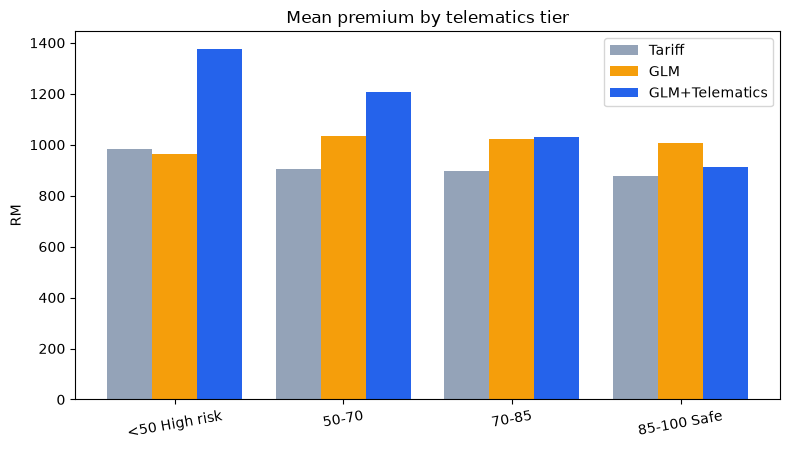

In [57]:
# Score bands from safe (85-100) to high-risk (<50): does dearer telematics
# premium actually sit where the losses are, per regime?
def tier_table(b):
    d = b.copy()
    d['tier'] = pd.cut(d['telematics_score'], bins=[0, 50, 70, 85, 100],
                       labels=['<50 High risk', '50-70', '70-85', '85-100 Safe'])
    g = d.groupby('tier', observed=False).agg(n=('POLID', 'size'), mean_prem=('FINAL_PREMIUM_SST', 'mean'),
                                              claims=('CLAIM_AMOUNT', 'sum'), prem_sum=('FINAL_PREMIUM_SST', 'sum'))
    g['lr'] = g['claims'] / g['prem_sum'] * 100
    return g[['n', 'mean_prem', 'lr']]

tiers = {m: tier_table(b) for m, b in books.items()}
tab = pd.DataFrame({f'{reg_label(m)} prem': tiers[m]['mean_prem'].round(0) for m in REGIMES_RUN})
tab = tab.join(pd.DataFrame({f'{reg_label(m)} LR': tiers[m]['lr'].round(1) for m in REGIMES_RUN}))
tab.index.name = 'Telematics tier'
display(tab)
x = np.arange(len(tab))
fig, ax = plt.subplots(figsize=(max(8, 2.5 * len(REGIMES_RUN)), 4.6))
w = 0.8 / len(REGIMES_RUN)
for i, m in enumerate(REGIMES_RUN):
    ax.bar(x + (i - (len(REGIMES_RUN) - 1) / 2) * w, tiers[m]['mean_prem'], w,
           label=reg_label(m), color=reg_color(m))
ax.set_xticks(x); ax.set_xticklabels(tab.index, rotation=10)
ax.set_title('Mean premium by telematics tier'); ax.set_ylabel('RM'); ax.legend()
plt.tight_layout(); plt.show()


## §7 EV vs ICE — share, frequency, severity, LR per year (first regime prices; counts identical)

,EV share,EV freq,EV sev/claim,EV LR,EV prem,ICE share,ICE freq,ICE sev/claim,ICE LR,ICE prem
SIM_YEAR,,,,,,,,,,
2026,4.1%,12.9%,"4,453",33.5%,"1,905",95.9%,11.2%,"6,601",82.2%,960
2027,5.3%,12.1%,"10,748",84.1%,"1,685",94.7%,11.4%,"5,437",76.6%,868
2028,7.4%,11.2%,"4,382",31.2%,"1,663",92.6%,11.5%,"5,634",87.4%,806
2029,10.0%,11.2%,"8,273",60.0%,"1,668",90.0%,10.9%,"6,157",94.4%,756
2030,13.6%,10.6%,"9,512",68.6%,"1,636",86.4%,10.3%,"5,684",86.9%,718


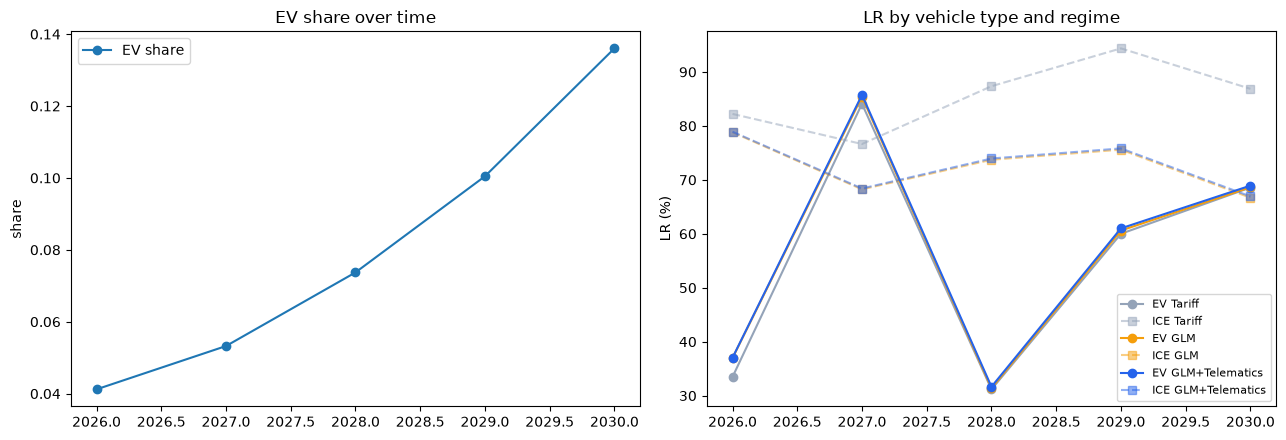

In [58]:
# EV costs more to assure and repair: check the book prices that in.
# Adoption-ramp scenarios need the EV-ramp engine TODO — out of scope here.
def evice(g):
    out = {}
    for nm in ('EV', 'ICE'):
        s = g[g.VEHICLE_TYPE == nm]
        n = s.CLAIM_COUNT.sum()
        out[nm + ' share'] = len(s) / len(g)
        out[nm + ' freq'] = s.CLAIM_OCCURRED.mean()
        out[nm + ' sev/claim'] = s.CLAIM_AMOUNT.sum() / n if n else float('nan')
        out[nm + ' LR'] = s.CLAIM_AMOUNT.sum() / s.FINAL_PREMIUM_SST.sum() if s.FINAL_PREMIUM_SST.sum() else float('nan')
        out[nm + ' prem'] = s.FINAL_PREMIUM_SST.mean()
    return pd.Series(out)

ev_df = books[REGIMES_RUN[0]].groupby('SIM_YEAR').apply(evice)
display(ev_df.style.format({'EV share': '{:.1%}', 'ICE share': '{:.1%}', 'EV freq': '{:.1%}',
                            'ICE freq': '{:.1%}', 'EV sev/claim': '{:,.0f}', 'ICE sev/claim': '{:,.0f}',
                            'EV LR': '{:.1%}', 'ICE LR': '{:.1%}',
                            'EV prem': '{:,.0f}', 'ICE prem': '{:,.0f}'}))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(ev_df.index, ev_df['EV share'], '-o', label='EV share')
axes[0].set_title('EV share over time'); axes[0].set_ylabel('share'); axes[0].legend()
for m in REGIMES_RUN:
    e = books[m].groupby('SIM_YEAR').apply(
        lambda g: pd.Series({'EV': g[g.VEHICLE_TYPE == 'EV'].CLAIM_AMOUNT.sum() / g[g.VEHICLE_TYPE == 'EV'].FINAL_PREMIUM_SST.sum(),
                              'ICE': g[g.VEHICLE_TYPE == 'ICE'].CLAIM_AMOUNT.sum() / g[g.VEHICLE_TYPE == 'ICE'].FINAL_PREMIUM_SST.sum()}))
    axes[1].plot(e.index, e['EV'] * 100, '-o', label=f"EV {reg_label(m)}", color=reg_color(m))
    axes[1].plot(e.index, e['ICE'] * 100, '--s', label=f"ICE {reg_label(m)}", color=reg_color(m), alpha=0.5)
axes[1].set_title('LR by vehicle type and regime'); axes[1].set_ylabel('LR (%)'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


## §8 Seed spread — every seed of every scenario (read from the manifest)
`run_scenarios.py` already ran each scenario once per seed in `seeds.json`; this section aggregates those results. No compute here — re-run the runner to refresh.

mean    p05     p95  P_LR_gt
scenario        regime                               
base_freq       glm     70.89  67.94   73.69     0.00
                tariff  81.38  78.25   84.28     1.00
                telem   71.05  68.08   73.93     0.08
base_freq_p10   glm     77.04  72.32   80.73     0.83
                tariff  88.39  83.38   92.88     1.00
                telem   77.22  72.49   80.91     0.83
base_freq_p15   glm     79.84  75.61   85.19     1.00
                tariff  91.60  86.96   97.47     1.00
                telem   80.02  75.82   85.43     1.00
base_freq_p20   glm     82.18  78.27   86.03     1.00
                tariff  94.21  90.47   98.71     1.00
                telem   82.38  78.46   86.26     1.00
base_freq_p25   glm     85.38  81.51   91.55     1.00
                tariff  97.80  92.96  104.82     1.00
                telem   85.58  81.71   91.76     1.00
high_adopt_freq glm     70.32  68.19   72.38     0.00
                tariff  80.24  77.98   81.97     1.00
                telem   70.48  68.33   72.49     0.00
low_adopt_freq  glm     70.71  67.10   74.29     0.00
                tariff  81.52  77.71   85.51     1.00
                telem   70.87  67.25   74.50     0.00

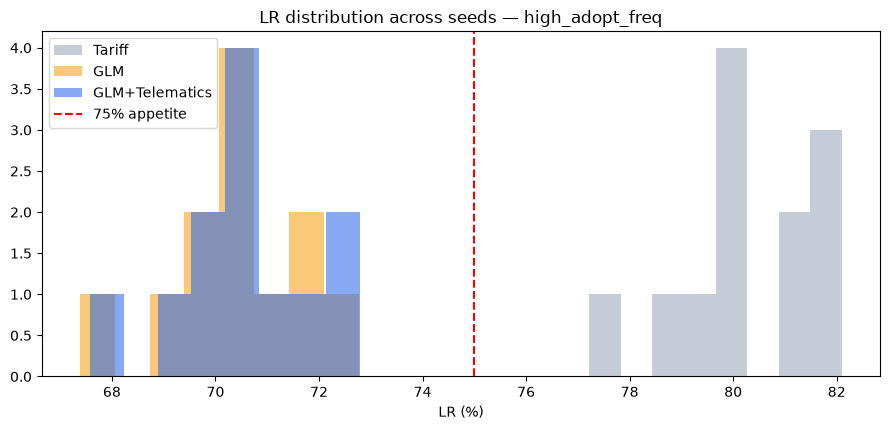

In [59]:
# Seed spread straight from the manifest — no re-simulation here.
# Refresh with `python run_scenarios.py` (one run per scenario x seed in seeds.json).
manifest = io.load_manifest()
rows = [{'scenario': entry['scenario'], 'seed': entry['seed'], 'regime': regime,
         'lr': metrics['lr']}
        for entry in manifest.values()
        for regime, metrics in entry['metrics'].items()]
mc = pd.DataFrame(rows)
appetite = 75
tab = mc.groupby(['scenario', 'regime'])['lr'].agg(
    mean='mean', p05=lambda x: x.quantile(.05), p95=lambda x: x.quantile(.95),
    P_LR_gt=lambda x: (x > appetite).mean())
display(tab.round(2))
here = mc[mc.scenario == SC]
fig, ax = plt.subplots(figsize=(9, 4.4))
for m in REGIMES_RUN:
    sub = here[here.regime == m]
    if len(sub):
        ax.hist(sub['lr'], bins=8, alpha=0.55, label=reg_label(m), color=reg_color(m))
ax.axvline(appetite, color='red', ls='--', label=f'{appetite}% appetite')
ax.legend(); ax.set_xlabel('LR (%)')
ax.set_title(f'LR distribution across seeds — {SC}')
plt.tight_layout(); plt.show()

## §10 Realism vs industry benchmarks
Compares this run against sourced Malaysian-market targets (`benchmarks.json`; search-derived from PIAM 2025 results, VTAREC theft data, NCD/excess sources). The default book passes 6/6.


In [60]:
import json
bench = json.load(open('benchmarks.json', encoding='utf-8'))
targets = {t['metric']: t for t in bench['targets']}

claims = raw[raw.CLAIM_COUNT > 0]
peril_sets = claims.CLAIM_PERIL.str.split('/')
def peril_rate(names):
    hit = peril_sets.apply(lambda s: any(n in s for n in names))
    return float(hit.sum()) / len(raw)

prem_book = books['tariff'] if 'tariff' in books else books[REGIMES_RUN[0]]
sim = {
    'own_damage_claim_rate': peril_rate(['AD', 'Windscreen']),
    'avg_claim_severity': float(claims.CLAIM_AMOUNT.mean()),
    'theft_claim_rate': peril_rate(['Theft']),
    'avg_private_car_premium': float(prem_book.FINAL_PREMIUM_SST.mean()),
    'retention_rate': float(raw.RENEWED.mean()),
    'portfolio_claims_ratio': lr(prem_book) / 100,
}
rows = []
for metric, value in sim.items():
    t = targets[metric]
    lo, hi = t['tolerance']
    rows.append({'Metric': metric, 'Sim': round(value, 4), 'Target': t['value'],
                 'Pass range': f'{lo} - {hi}',
                 'Status': 'PASS' if lo <= value <= hi else 'FAIL',
                 'Source': t['source'].split('(')[0].strip()})
display(pd.DataFrame(rows))
print(f"reality checks passed: {(pd.DataFrame(rows).Status == 'PASS').sum()}/{len(rows)}")


,Metric,Sim,Target,Pass range,Status,Source
0,own_damage_claim_rate,0.0722,0.0900,0.05 - 0.14,PASS,PIAM 2025: private car claim frequency above 7%
1,avg_claim_severity,6515.8100,8831.0000,6000 - 13000,PASS,"PIAM 2025: claim severity RM8,831"
2,theft_claim_rate,0.0014,0.0015,0.0005 - 0.004,PASS,VTAREC/Star: ~13k vehicle thefts per year vs ~...
3,avg_private_car_premium,891.1511,950.0000,700 - 1300,PASS,PIAM average private vehicle premium RM857
4,retention_rate,0.9039,0.8500,0.75 - 0.92,PASS,motor renewal rates commonly 80-90%
5,portfolio_claims_ratio,0.8096,0.7500,0.62 - 0.85,PASS,Derived from PIAM 2025 motor combined ratio 10...


reality checks passed: 6/6


## §11 Explainability — GLM & telematics (SHAP)

For a **linear** model the SHAP values are exact and cheap: contribution of
feature `j` to policy `i` is `coef_j × (x_ij − E[x_j])`, measured against the
training-sample means. Values are in **log-rate space** (additive), so `exp(ϕ)`
reads as a ×multiplier.

Premium follows the same log decomposition:

```
log premium = log freq (model) + log severity + log(1 / target_lr)
              + log(1 - NCD) + flags × log risk_step
```

NCD is a statutory discount applied to the model output, never a learned
feature (TPO policies are exempt); `target_lr` is the pure-premium anchor.
Both models below are refit through the SAME code path the pricer uses
(`methods/glm.py`, `methods/telem.py` → `train_model`), so the attribution is to
the exact model that produced the priced book. Training data comes from the
base template world (rule), scored on the run loaded above.

In [61]:
import shap  # pip install shap
import numpy as np
import pandas as pd
from voltvision import load_template, resolve_cards, ensure_core_methods, Card
ensure_core_methods()  # every card resolves, even in a fresh kernel
from voltvision.ml import encode_features, severity_by_row
from voltvision.methods.glm import train_model as train_glm, FEATURES as GLM_FEATURES
from voltvision.methods.telem import train_model as train_telem, FEATURES as TELEM_FEATURES

cfg = load_template()
cards = resolve_cards(cfg)
card_g = Card(cards['glm'])
card_t = Card(cards['telem'])
model_g, sev_g, covsev_g, rows_g = train_glm(raw, card_g, cfg, base_cfg=cfg)
model_t, sev_t, covsev_t, rows_t = train_telem(raw, card_t, cfg, base_cfg=cfg)

FEAT_NAME = {'DRIVER_AGE': 'driver age', 'CAR_AGE': 'car age',
             'VEHICLE_TYPE': 'fuel', 'COVERAGE_TYPE': 'coverage', 'FLOOD_RISK': 'flood flag',
             'THEFT_RISK': 'theft flag', 'REGION': 'region',
             'telematics_score': 'telematics score'}


def shap_table(model, feats, background):
    # Exact linear SHAP on the log-rate predictor: coef_j * (x_j - E[x_j]).
    X = encode_features(raw, feats)
    mean = encode_features(background, feats).mean()
    coef = pd.Series(model.coef_, index=feats)
    phi = X.sub(mean).mul(coef, axis=1)
    lp = X.to_numpy(dtype=float) @ model.coef_ + model.intercept_
    assert np.allclose(phi.sum(axis=1) + model.intercept_ + float(mean @ coef), lp)
    return phi, float(model.intercept_ + mean @ coef), X


phi_g, base_g, X_g = shap_table(model_g, GLM_FEATURES, rows_g)
phi_t, base_t, X_t = shap_table(model_t, TELEM_FEATURES, rows_t)

# Display frame: pretty names + category labels (for readable plots).
def display_frame(X, feats):
    disp = X.copy()
    for c in ('VEHICLE_TYPE', 'COVERAGE_TYPE', 'REGION'):
        cats = raw[c].astype('category').cat.categories
        disp[c] = X[c].map(dict(enumerate(cats)))
    return disp.rename(columns=FEAT_NAME)


disp_g, disp_t = display_frame(X_g, GLM_FEATURES), display_frame(X_t, TELEM_FEATURES)
SAMPLE = np.random.default_rng(7).choice(len(raw), size=3000, replace=False)
print('models refit on the same code path | scored rows', len(raw),
      '| plot sample', len(SAMPLE))
print('mean log-rate  GLM %.3f  telem %.3f' % (float((X_g.to_numpy(dtype=float) @ model_g.coef_ + model_g.intercept_).mean()),
                                               float((X_t.to_numpy(dtype=float) @ model_t.coef_ + model_t.intercept_).mean())))

models refit on the same code path | scored rows 53825 | plot sample 3000
mean log-rate  GLM -2.186  telem -2.193


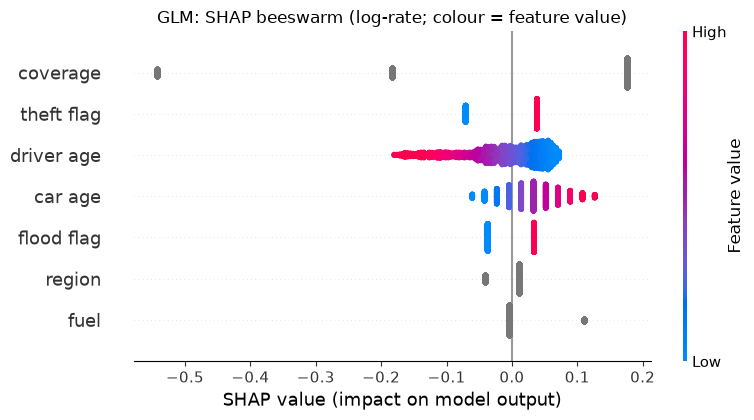

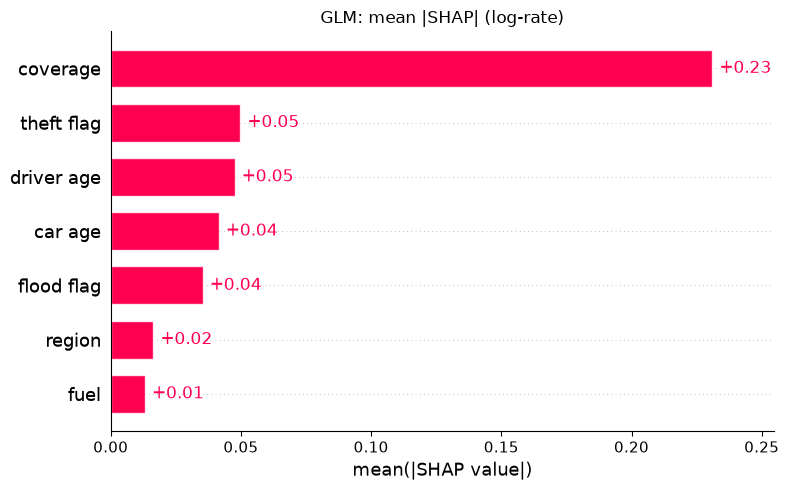

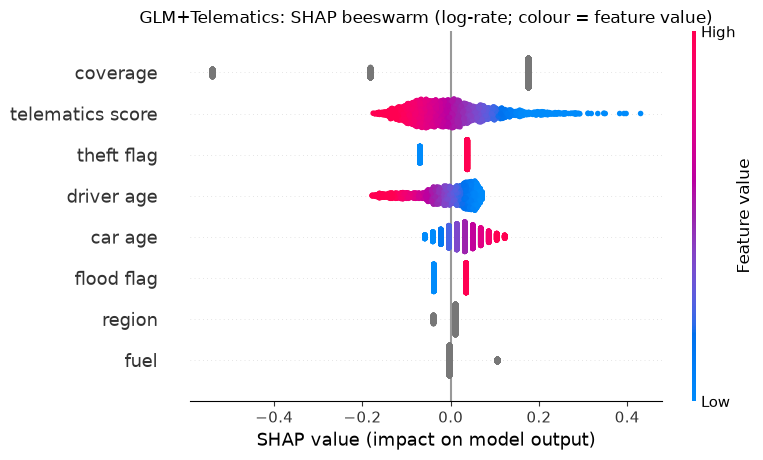

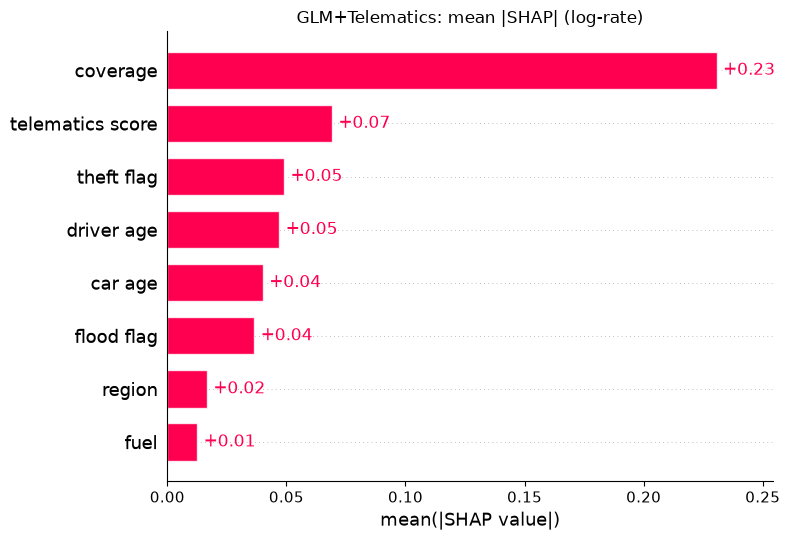

In [62]:
def explanation(model_phi, base, disp):
    return shap.Explanation(values=model_phi.values[SAMPLE],
                            base_values=np.full(len(SAMPLE), base),
                            data=disp.values[SAMPLE], feature_names=list(disp.columns))

for label, phi, base, disp in (('GLM', phi_g, base_g, disp_g),
                               ('GLM+Telematics', phi_t, base_t, disp_t)):
    exp = explanation(phi, base, disp)
    fig = plt.figure(figsize=(9, 4.8))
    shap.plots.beeswarm(exp, max_display=9, show=False)
    plt.title(f'{label}: SHAP beeswarm (log-rate; colour = feature value)')
    plt.tight_layout(); plt.show()
    fig = plt.figure(figsize=(7, 4.2))
    shap.plots.bar(exp, max_display=9, show=False)
    plt.title(f'{label}: mean |SHAP| (log-rate)')
    plt.tight_layout(); plt.show()

<Figure size 700x360 with 0 Axes>

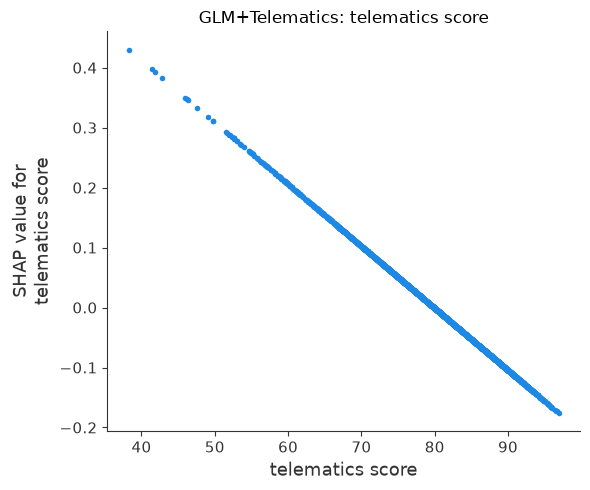

<Figure size 700x360 with 0 Axes>

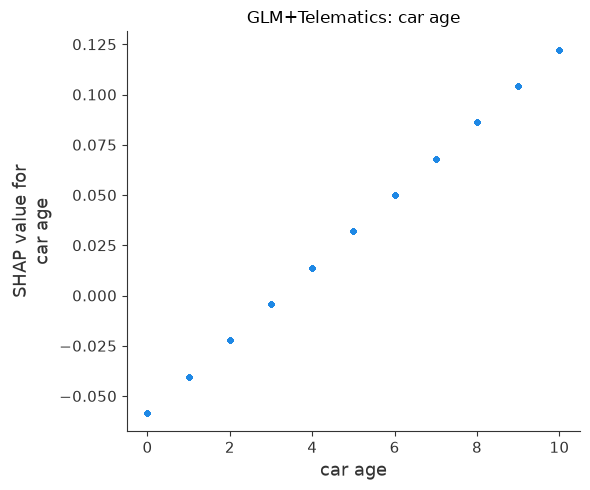

<Figure size 700x360 with 0 Axes>

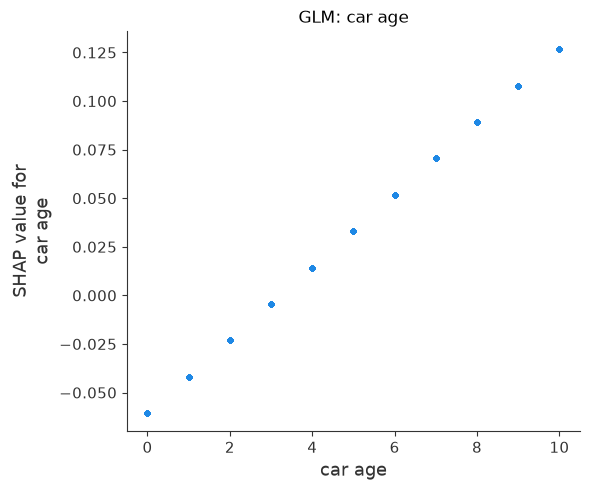

In [63]:
# Dependence: how single features move the log-rate (telem model for the score).
for label, phi, disp in (('GLM+Telematics', phi_t, disp_t), ('GLM', phi_g, disp_g)):
    for feature in ('telematics score', 'car age'):
        if feature not in disp.columns:
            continue
        fig = plt.figure(figsize=(7, 3.6))
        shap.dependence_plot(feature, phi.values[SAMPLE], disp.iloc[SAMPLE], interaction_index=None, show=False)
        plt.title(f'{label}: {feature}')
        plt.tight_layout(); plt.show()

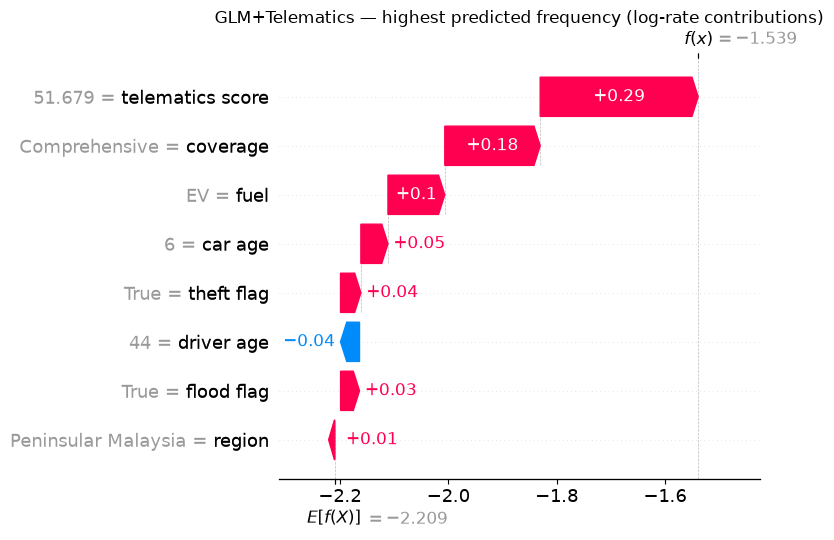

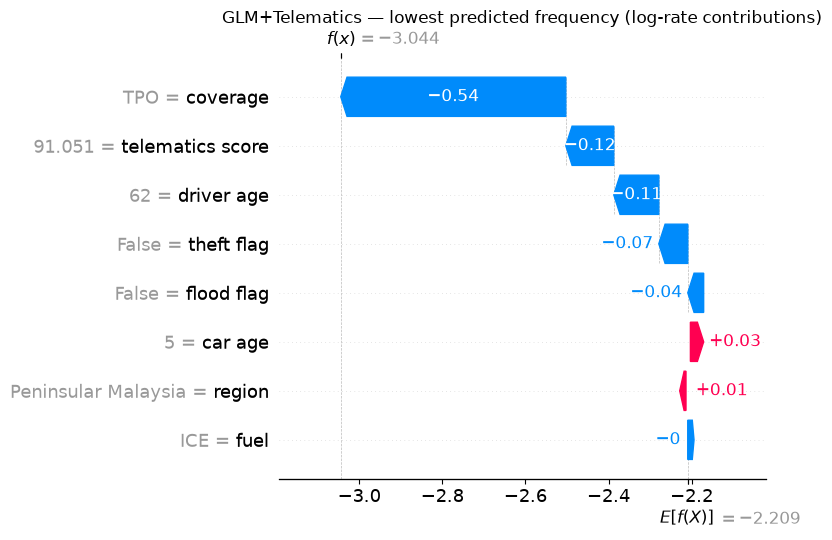

In [64]:
# Waterfall: the riskiest and the safest policies in the plot sample (telem model).
lp_t = X_t.to_numpy(dtype=float) @ model_t.coef_ + model_t.intercept_
hi, lo = SAMPLE[int(np.argmax(lp_t[SAMPLE]))], SAMPLE[int(np.argmin(lp_t[SAMPLE]))]
for idx, tag in ((hi, 'highest predicted frequency'), (lo, 'lowest predicted frequency')):
    exp_row = shap.Explanation(values=phi_t.values[idx], base_values=base_t,
                               data=disp_t.values[idx],
                               feature_names=list(disp_t.columns))
    fig = plt.figure(figsize=(9, 4.2))
    shap.plots.waterfall(exp_row, max_display=9, show=False)
    plt.title(f'GLM+Telematics — {tag} (log-rate contributions)')
    plt.tight_layout(); plt.show()

,GLM mean|SHAP|,Telem mean|SHAP|,delta (telem - glm)
fuel,0.0131,0.0125,-0.0006
region,0.0163,0.0165,0.0002
flood flag,0.0353,0.0365,0.0012
car age,0.0418,0.0403,-0.0014
driver age,0.0483,0.0477,-0.0006
theft flag,0.0497,0.0490,-0.0008
telematics score,0.0000,0.0683,0.0683
coverage,0.2345,0.2341,-0.0004


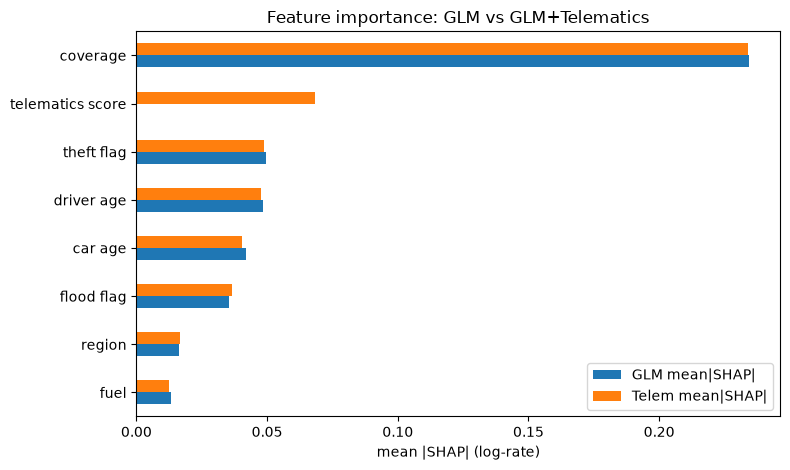

In [65]:
# How do attributions shift when telematics_score joins the model?
mg = phi_g.abs().mean().rename(index=FEAT_NAME)
mt = phi_t.abs().mean().rename(index=FEAT_NAME)
tab = pd.DataFrame({'GLM mean|SHAP|': mg, 'Telem mean|SHAP|': mt}).fillna(0.0)
tab['delta (telem - glm)'] = tab['Telem mean|SHAP|'] - tab['GLM mean|SHAP|']
tab = tab.sort_values('Telem mean|SHAP|', ascending=True)
display(tab.round(4))
ax = tab[['GLM mean|SHAP|', 'Telem mean|SHAP|']].plot.barh(figsize=(8, 4.8))
ax.set_xlabel('mean |SHAP| (log-rate)')
ax.set_title('Feature importance: GLM vs GLM+Telematics')
plt.tight_layout(); plt.show()

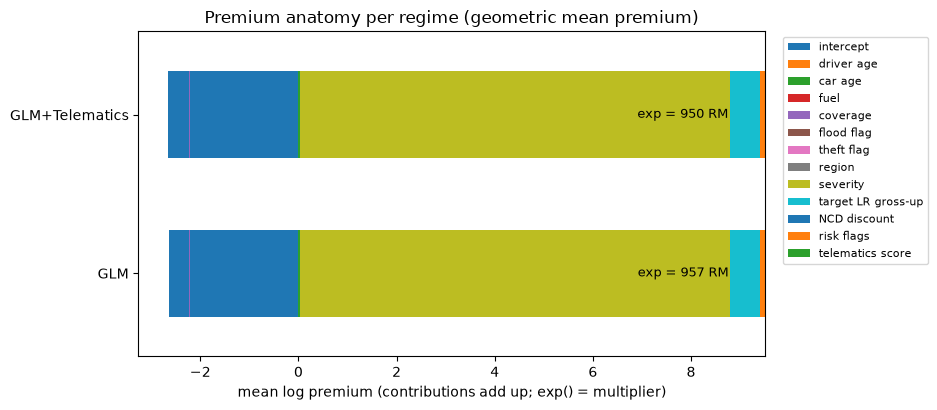

arithmetic mean premium (actual): {'glm': 1019, 'telem': 1016}


In [66]:
# Premium anatomy: mean log-premium split into model attributions + severity,
# target-LR gross-up, the post-model NCD discount and risk flags
# (exp() of each part reads as a multiplier).
def anatomy(label, phi, base, model, card, sev, covsev, flags):
    parts = {'intercept': base, **{FEAT_NAME[c]: float(phi[c].mean()) for c in phi.columns}}
    parts['severity'] = float(np.log(severity_by_row(raw, sev, covsev)).mean())
    parts['target LR gross-up'] = float(np.log(1.0 / card.target_lr))
    ncd_keep = np.where(raw['COVERAGE_TYPE'].values == 'TPO', 1.0,
                        1 - raw['NCD_LEVEL'].values)
    parts['NCD discount'] = float(np.log(ncd_keep).mean())
    parts['risk flags'] = float(flags.mean())
    total = sum(parts.values())
    log_prem = float((np.log(model.predict(encode_features(raw, list(phi.columns)))
                             * severity_by_row(raw, sev, covsev) / card.target_lr * ncd_keep)
                      + flags).mean())
    assert np.isclose(total, log_prem)
    return pd.Series(parts, name=label), total


flags_count = raw['FLOOD_RISK'].values.astype(int) + raw['THEFT_RISK'].values.astype(int)
flags_log = flags_count * np.log(card_g.risk_step)
an_g, tot_g = anatomy('GLM', phi_g, base_g, model_g, card_g, sev_g, covsev_g, flags_log)
an_t, tot_t = anatomy('GLM+Telematics', phi_t, base_t, model_t, card_t, sev_t, covsev_t, flags_log)

anat = pd.DataFrame([an_g, an_t]).fillna(0.0)
ax = anat.plot.barh(stacked=True, figsize=(9.5, 4.2), width=0.55)
ax.set_xlabel('mean log premium (contributions add up; exp() = multiplier)')
ax.set_title('Premium anatomy per regime (geometric mean premium)')
for y, tot in enumerate((tot_g, tot_t)):
    ax.text(tot + 0.05, y, f'exp = {np.exp(tot):,.0f} RM', va='center', fontsize=9)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()
print('arithmetic mean premium (actual):', {m: round(io.books_from_result(combined)[m].FINAL_PREMIUM_SST.mean())
      for m in ('glm', 'telem')})

Notes

- SHAP values here are exact (linear model), in **log-rate** units; `exp(ϕ)`
  is the ×multiplier that policy's feature applies to the base rate.
- NCD is not a model feature: the statutory discount enters as the
  post-model `NCD discount` segment (TPO-exempt), like the tariff formula.
- The premium anatomy stacks model attributions with the shared severity table,
  the `target_lr` gross-up and risk-flag multipliers; `exp(total)` is the geometric mean
  premium, slightly below the arithmetic mean printed at the end (Jensen).
- Telematics gains importance only through `telematics_score`; everything else
  is the GLM set — the delta table quantifies that.

## §12 Premium evolution — GLM (and peers) across policy years

Two views of how the same pricing mechanics evolve over the book's life
(premiums include the post-model NCD discount):

1. **Portfolio mean** premium by `SIM_YEAR`, averaged across every seed the
   manifest holds for this scenario; the band is the seed min–max. Entrant
   and lapse composition make a single seed jitter at the ±2% level after
   the first renewal step — that is sampling noise, not pricing instability
   (there are no per-year refits).
2. **Cohort-matched path** — only policies born in `cohort_year` and still
   in-force, averaged by year. Removing entrant/lapse composition isolates
   the genuine drift from driver ageing, car ageing and NCD accumulation;
   this is the smooth curve to read premium evolution from.

All regimes present in the file are plotted (never read one alone); GLM is
the focus.

high_adopt_freq: seeds [7, 13, 21, 42, 58, 67, 69, 91, 103, 157, 203, 299] | cohort born 2026


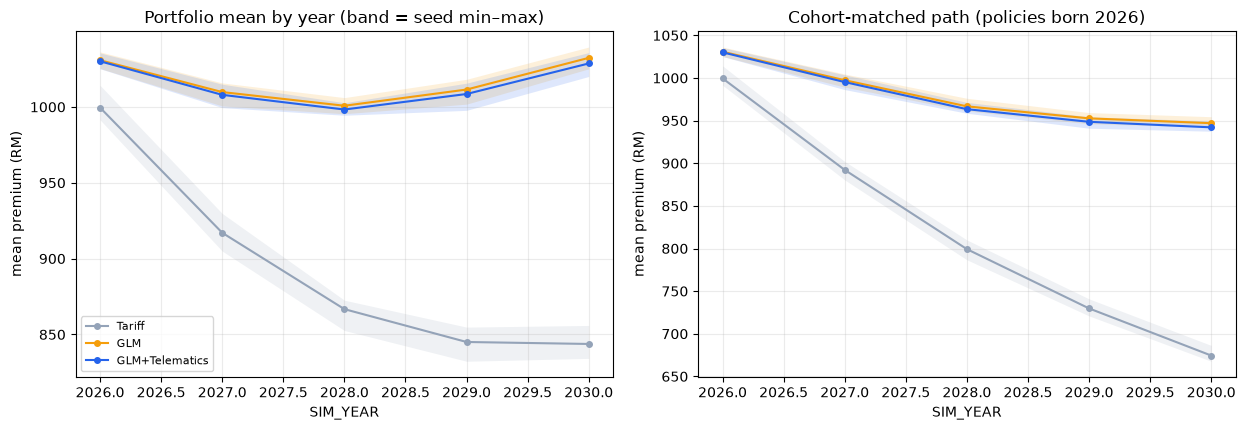

cohort-matched year-over-year change (%):


,Tariff,GLM,GLM+Telematics
SIM_YEAR,,,
2026,NaN,NaN,NaN
2027,-10.74,-3.24,-3.39
2028,-10.42,-3.07,-3.19
2029,-8.70,-1.46,-1.54
2030,-7.57,-0.60,-0.69


In [67]:
# Every seed recorded for this scenario — the manifest is the source of truth.
manifest = io.load_manifest()
SEEDS_SC = sorted({int(e['seed']) for e in manifest.values() if e['scenario'] == SC})
COHORT0 = int(raw['COHORT_YEAR'].min())
print(f'{SC}: seeds {SEEDS_SC} | cohort born {COHORT0}')


def seed_band(regime, cohort_only=False):
    rows = []
    for s in SEEDS_SC:
        try:
            b = io.books_from_result(io.load_result(SC, s))[regime]
        except FileNotFoundError:
            continue
        if cohort_only:
            b = b[b['COHORT_YEAR'] == COHORT0]
        rows.append(b.groupby('SIM_YEAR')['FINAL_PREMIUM_SST'].mean().rename(s))
    return pd.concat(rows, axis=1) if rows else None


def draw_evolution(ax, cohort_only, title):
    for regime in REGIMES_RUN:
        band = seed_band(regime, cohort_only)
        if band is None or band.empty:
            continue
        ax.plot(band.index, band.mean(axis=1), marker='o', ms=4,
                color=reg_color(regime), label=reg_label(regime))
        ax.fill_between(band.index, band.min(axis=1), band.max(axis=1),
                        color=reg_color(regime), alpha=0.15, lw=0)
    ax.set_title(title)
    ax.set_xlabel('SIM_YEAR')
    ax.set_ylabel('mean premium (RM)')
    ax.grid(alpha=0.25)


fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))
draw_evolution(axes[0], False, 'Portfolio mean by year (band = seed min–max)')
draw_evolution(axes[1], True, f'Cohort-matched path (policies born {COHORT0})')
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

# Smoothness evidence: year-over-year change of the cohort-matched seed-mean lines.
chg = {reg_label(r): seed_band(r, True).mean(axis=1).pct_change() * 100
       for r in REGIMES_RUN if seed_band(r, True) is not None}
print('cohort-matched year-over-year change (%):')
display(pd.DataFrame(chg).round(2))

## §13 Stress-suite comparison — scenario cards vs outputs

Reads the manifest (`cfg` + `cards` + `metrics`) for every run. Three views:

1. **Scenario cards** — the levers each stress scenario patches vs base.
2. **Outputs** — LR / avg premium per regime, aggregated over seeds (mean, p05, p95).
3. **Checks** — frequency-intensity realised rate, and long-run NCD/LR convergence.


In [68]:
# 1) Scenario cards — key levers per scenario, pulled from the manifest cfg.
manifest = io.load_manifest()
names = sorted({e['scenario'] for e in manifest.values()})
cfg_of = {e['scenario']: e['cfg'] for e in manifest.values()}

def lever_row(cfg):
    vto = (cfg.get('vehicle_ramp') or {}).get('to') or {}
    cto = (cfg.get('coverage_ramp') or {}).get('to') or {}
    gp = cfg.get('generation_pct', {})
    return {
        'freq_intensity': cfg.get('frequency_intensity', 1.0),
        'n_years': cfg.get('n_years'),
        'sev_inflation': cfg.get('severity_inflation'),
        'sev_mult': cfg.get('severity_multiplier', 1.0),
        'entrant_frac': cfg.get('entrant_frac'),
        'EV_to': vto.get('EV', '-'),
        'TPO_to': cto.get('TPO', '-'),
        'senior_pct': gp.get('Seniors', '-'),
        'young_pct': gp.get('Young Adults', '-'),
        'male_pct': cfg.get('gender_pct', {}).get('Male', '-'),
        'flood_prob': max((cfg.get('flood_event_prob') or {}).values(), default='-'),
        'theft_prob': max((cfg.get('risk_flags', {}).get('theft') or {}).values(), default='-'),
    }

cards = pd.DataFrame({n: lever_row(cfg_of[n]) for n in names}).T
display(cards)


,freq_intensity,n_years,sev_inflation,sev_mult,entrant_frac,EV_to,TPO_to,senior_pct,young_pct,male_pct,flood_prob,theft_prob
base_freq,1.0,5,0.06,1.0,0.13,0.2,-,0.05,0.4,0.55,0.4,0.85
base_freq_p10,1.1,5,0.06,1.0,0.13,0.2,-,0.05,0.4,0.55,0.4,0.85
base_freq_p15,1.15,5,0.06,1.0,0.13,0.2,-,0.05,0.4,0.55,0.4,0.85
base_freq_p20,1.2,5,0.06,1.0,0.13,0.2,-,0.05,0.4,0.55,0.4,0.85
base_freq_p25,1.25,5,0.06,1.0,0.13,0.2,-,0.05,0.4,0.55,0.4,0.85
high_adopt_freq,1.0,5,0.06,1.0,0.13,0.38,-,0.05,0.4,0.55,0.4,0.85
low_adopt_freq,1.0,5,0.06,1.0,0.13,0.1,-,0.05,0.4,0.55,0.4,0.85


In [69]:
# 2) Outputs — LR / premium per scenario x regime, aggregated over seeds.
rows = []
for e in manifest.values():
    for regime, mm in e['metrics'].items():
        rows.append({'scenario': e['scenario'], 'regime': regime,
                     'lr': mm['lr'], 'avg_prem': mm['avg_prem']})
out = pd.DataFrame(rows)
piv = out.groupby(['scenario', 'regime']).agg(
    lr_mean=('lr', 'mean'), lr_p05=('lr', lambda x: x.quantile(.05)),
    lr_p95=('lr', lambda x: x.quantile(.95)), prem=('avg_prem', 'mean')).round(1)
display(piv)


lr_mean  lr_p05  lr_p95    prem
scenario        regime                                 
base_freq       glm        70.9    67.9    73.7  1002.0
                tariff     81.4    78.2    84.3   873.0
                telem      71.1    68.1    73.9   999.8
base_freq_p10   glm        77.0    72.3    80.7  1010.4
                tariff     88.4    83.4    92.9   880.7
                telem      77.2    72.5    80.9  1008.1
base_freq_p15   glm        79.8    75.6    85.2  1015.2
                tariff     91.6    87.0    97.5   885.0
                telem      80.0    75.8    85.4  1012.8
base_freq_p20   glm        82.2    78.3    86.0  1018.5
                tariff     94.2    90.5    98.7   888.5
                telem      82.4    78.5    86.3  1016.0
base_freq_p25   glm        85.4    81.5    91.5  1023.3
                tariff     97.8    93.0   104.8   893.3
                telem      85.6    81.7    91.8  1020.9
high_adopt_freq glm        70.3    68.2    72.4  1017.1
                tariff     80.2    78.0    82.0   891.4
                telem      70.5    68.3    72.5  1014.8
low_adopt_freq  glm        70.7    67.1    74.3   993.2
                tariff     81.5    77.7    85.5   861.4
                telem      70.9    67.2    74.5   991.2

In [70]:
# 3a) Frequency-intensity verification — realised rate should scale ~x1.10/1.20/1.25.
sc = ['base', 'freq_p10', 'freq_p20', 'freq_p25']
chk = []
for s in sc:
    for e in manifest.values():
        if e['scenario'] != s:
            continue
        b = io.load_result(s, e['seed'])
        chk.append({'scenario': s,
                    'freq': b['CLAIM_OCCURRED'].mean(),
                    'lr_tariff': lr(io.books_from_result(b)['tariff']),
                    'lr_glm': lr(io.books_from_result(b)['glm'])})
chk = pd.DataFrame(chk).groupby('scenario').mean()
chk['freq_ratio'] = (chk['freq'] / chk.loc['base', 'freq']).round(3)
display(chk.round(2))


KeyError: 'scenario'

In [ ]:
# 3b) Long-run convergence — LR and NCD level by policy year (30y, zero inflation/growth).
lr_b = io.load_result('long_run_30y', 42)
tar = io.books_from_result(lr_b)['telem']
years = sorted(tar.SIM_YEAR.unique())
lr_yr = [lr(tar[tar.SIM_YEAR == y]) for y in years]
ncd = lr_b.groupby('SIM_YEAR')['NCD_LEVEL'].mean()
lr_trend = np.poly1d(np.polyfit(years, lr_yr, 1))
ncd_trend = np.poly1d(np.polyfit(years, ncd.values, 1))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(years, lr_yr, 'o-', color=reg_color('telem'), label='LR')
ax[0].plot(years, lr_trend(years), '--', color='#333',
           label=f'trend {lr_trend[0]:+.2f} pp/yr')
ax[0].axhline(100, color='red', ls='--')
ax[0].set_xlabel('Policy year'); ax[0].set_ylabel('tele LR (%)')
ax[0].set_title('Long-run LR (30y, zero inflation/growth)'); ax[0].legend()
ax[1].plot(years, ncd.values, 's-', color='#f59e0b', label='NCD')
ax[1].plot(years, ncd_trend(years), '--', color='#333',
           label=f'trend {ncd_trend[0]:+.4f} /yr')
ax[1].set_xlabel('Policy year'); ax[1].set_ylabel('Mean NCD level')
ax[1].set_title('NCD distribution convergence'); ax[1].legend()
plt.tight_layout(); plt.show()


FileNotFoundError: shared/results/long_run_30y_s42.pkl missing — run run_scenarios.py first